In [7]:
## AR2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde
from tqdm import tqdm
import os 
from pathlib import Path

def generate_ar2_drw(phi1, phi2, noise_std, n_samples=256):
    # allocate
    x = np.zeros(n_samples)

    # gaussian noise
    eps = np.random.randn(n_samples) * noise_std

    # initialize first two points
    x[0] = eps[0]
    x[1] = eps[1]

    # AR(2) recursion
    for t in range(2, n_samples):
        x[t] = phi1 * x[t - 1] + phi2 * x[t - 2] + eps[t]

    return x

def estimate_ar2_coeffs_from_cov(curves):
    """
    curves: ndarray [B, N]
    returns: ndarray [B, 2] with estimated (phi1, phi2)
    """

    x = curves[:]     # [B, N']
    B, N = x.shape

    # center per curve
    x = x - x.mean(axis=1, keepdims=True)

    # autocovariances γ(0), γ(1), γ(2)
    g0 = np.sum(x * x, axis=1) / N
    g1 = np.sum(x[:, 1:] * x[:, :-1], axis=1) / (N - 1)
    g2 = np.sum(x[:, 2:] * x[:, :-2], axis=1) / (N - 2)

    # Yule–Walker system
    A = np.stack(
        [
            np.stack([g0, g1], axis=1),
            np.stack([g1, g0], axis=1),
        ],
        axis=1,
    )                                  # [B, 2, 2]

    b = np.stack([g1, g2], axis=1)     # [B, 2]

    phi = np.linalg.solve(A, b)        # [B, 2]

    return phi

import numpy as np

def residual_autocorrelation_ar2(curves, max_lag=20):
    """
    Compute residual autocorrelation after fitting AR(2) models.

    Parameters
    ----------
    curves : ndarray [B, N]
        Batch of time series.
    max_lag : int
        Maximum lag for autocorrelation.

    Returns
    -------
    resid_acf : ndarray [B, max_lag]
        Residual autocorrelation for each lag.

    whiteness_score : ndarray [B]
        Mean absolute residual autocorrelation.
        Smaller = better AR(2) fit.

    phi : ndarray [B, 2]
        Estimated AR(2) coefficients.
    """

    x = curves.copy()

    B, N = x.shape

    # center curves
    x = x - x.mean(axis=1, keepdims=True)

    # autocovariances
    g0 = np.sum(x * x, axis=1) / N
    g1 = np.sum(x[:, 1:] * x[:, :-1], axis=1) / (N - 1)
    g2 = np.sum(x[:, 2:] * x[:, :-2], axis=1) / (N - 2)

    # Yule-Walker system
    A = np.stack(
        [
            np.stack([g0, g1], axis=1),
            np.stack([g1, g0], axis=1),
        ],
        axis=1,
    )  # [B, 2, 2]

    b = np.stack([g1, g2], axis=1)  # [B, 2]

    phi = np.linalg.solve(A, b)  # [B, 2]

    phi1 = phi[:, 0]
    phi2 = phi[:, 1]

    # AR(2) prediction residuals
    pred = (
        phi1[:, None] * x[:, 1:-1]
        + phi2[:, None] * x[:, :-2]
    )

    resid = x[:, 2:] - pred

    # center residuals
    resid = resid - resid.mean(axis=1, keepdims=True)

    denom = np.sum(resid**2, axis=1)

    acfs = []

    for lag in range(1, max_lag + 1):

        numer = np.sum(
            resid[:, lag:] * resid[:, :-lag],
            axis=1
        )

        acf = numer / denom

        acfs.append(acf)

    resid_acf = np.stack(acfs, axis=1)

    # scalar goodness-of-fit metric
    whiteness_score = np.mean(np.abs(resid_acf), axis=1)

    return resid_acf, whiteness_score, phi

def sample_mixture(centers, covs, weights, n_samples=8000, max_sum=0.93, oversample_factor=1.2):
    """
    Fast vectorized mixture sampler with max_sum constraint.
    Uses large-batch sampling for efficiency.
    """
    samples = []

    for center, cov, w in zip(centers, covs, weights):
        target_count = int(n_samples * w)
        collected = []

        # large batch size (vectorized sampling)
        batch_size = int(target_count * oversample_factor)

        while True:
            # sample a large batch
            batch = np.random.multivariate_normal(center, cov, size=batch_size)

            # vectorized constraint
            mask = np.abs(batch).sum(axis=1) <= max_sum
            valid = batch[mask]

            collected.append(valid)

            # check if enough accepted
            total = sum(len(c) for c in collected)
            if total >= target_count:
                break

        # concatenate once and trim
        collected = np.vstack(collected)[:target_count]
        samples.append(collected)

    return np.vstack(samples)

def generate_ar2_curves_from_coeffs(coeffs, noise_std=0.3, n_samples=256):
    """
    coeffs: array or tensor of shape [B, 2]
    returns: numpy array [B, n_samples]
    """
    coeffs = np.asarray(coeffs)
    curves = []

    for phi1, phi2 in tqdm(coeffs, "generating curves"):
        curve = generate_ar2_drw(phi1, phi2, noise_std=noise_std, n_samples=n_samples)
        curves.append(curve)

    return np.stack(curves, axis=0)

In [8]:
## AR1
def estimate_ar1_coeffs_from_cov(curves):
    """
    curves: ndarray [B, N]
    returns: ndarray [B, 1] with estimated AR(1) coefficient phi
    """

    # remove burn-in
    x = curves[:]          # [B, N']
    B, N = x.shape

    # center each curve
    x = x - x.mean(axis=1, keepdims=True)

    # autocovariances γ(0) and γ(1)
    g0 = np.sum(x * x, axis=1) / N
    g1 = np.sum(x[:, 1:] * x[:, :-1], axis=1) / (N - 1)

    # AR(1) Yule–Walker
    phi = (g1 / g0)[:, None]         # [B, 1]

    return phi

import numpy as np

def residual_autocorrelation_ar1(curves, max_lag=20):
    """
    Compute residual autocorrelation after fitting AR(1) models.

    Parameters
    ----------
    curves : ndarray [B, N]
        Batch of time series.
    max_lag : int
        Maximum lag for autocorrelation.

    Returns
    -------
    resid_acf : ndarray [B, max_lag]
        Residual autocorrelation for each lag.
    whiteness_score : ndarray [B]
        Mean absolute residual autocorrelation.
        Smaller = better AR(1) fit.
    phi : ndarray [B]
        Estimated AR(1) coefficients.
    """

    x = curves.copy()

    B, N = x.shape

    # center curves
    x = x - x.mean(axis=1, keepdims=True)

    # estimate AR(1) coefficient using Yule-Walker
    g0 = np.sum(x * x, axis=1) / N
    g1 = np.sum(x[:, 1:] * x[:, :-1], axis=1) / (N - 1)

    phi = g1 / g0  # [B]

    # AR(1) prediction residuals
    resid = x[:, 1:] - phi[:, None] * x[:, :-1]

    # center residuals
    resid = resid - resid.mean(axis=1, keepdims=True)

    denom = np.sum(resid**2, axis=1)

    acfs = []

    for lag in range(1, max_lag + 1):

        numer = np.sum(
            resid[:, lag:] * resid[:, :-lag],
            axis=1
        )

        acf = numer / denom

        acfs.append(acf)

    resid_acf = np.stack(acfs, axis=1)

    # scalar goodness-of-fit metric
    whiteness_score = np.mean(np.abs(resid_acf), axis=1)

    return resid_acf, whiteness_score, phi

def sample_ar1_from_kde(kde, n_samples=5000, max_val=0.97):
    """
    Samples AR(1) coefficients from the KDE.
    Enforces a maximum stability constraint phi <= max_val.
    """
    samples = []

    batch = int(n_samples * 1.5)
    while len(samples) < n_samples:
        # sample from KDE (scipy supports resampling)
        batch_samples = kde.resample(batch).reshape(-1)

        # keep only stable AR(1) coefficients
        batch_samples = batch_samples[batch_samples <= max_val]

        samples.append(batch_samples)

        if sum(len(s) for s in samples) >= n_samples:
            break

    samples = np.concatenate(samples)[:n_samples]
    return samples

def generate_ar1_curves(phi_list, noise_std=1, n_samples=256):
    """
    phi_list: array [N] of AR(1) damping coefficients
    Returns curves: [N, n_samples]
    """
    N = len(phi_list)
    curves = np.zeros((N, n_samples))

    for i, phi in enumerate(phi_list):
        x = np.zeros(n_samples)
        for t in range(1, n_samples):
            x[t] = phi * x[t-1] + np.random.randn() * noise_std
        curves[i] = x

    return curves


In [9]:
## Plotting
def plot_coeff_kde(
    coeffs,
    grid_size=250,
    cmap="viridis",
    title=None,
    ax=None,
    add_colorbar=True,
):
    coeffs = np.asarray(coeffs)
    phi1 = coeffs[:, 0]
    phi2 = coeffs[:, 1]

    kde = gaussian_kde(coeffs.T)

    xgrid = np.linspace(phi1.min(), phi1.max(), grid_size)
    ygrid = np.linspace(phi2.min(), phi2.max(), grid_size)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)

    if ax is None:
        ax = plt.gca()

    img = ax.imshow(
        Z,
        origin="lower",
        extent=[phi1.min(), phi1.max(), phi2.min(), phi2.max()],
        aspect="auto",
        cmap=cmap,
    )

    ax.set_xlabel("phi1")
    ax.set_ylabel("phi2")
    if title is not None:
        ax.set_title(title)

    if add_colorbar:
        plt.colorbar(img, ax=ax)

    return img

def plot_ar1_kde(xgrid, density, x_label="Estimated AR(1) phi", y_label="Density", title="1D KDE of AR(1) Coefficients Fitted to AR(2) Curves"):
    ax = plt.gca()

    ax.plot(xgrid, density, linewidth=3)
    ax.fill_between(xgrid, density, alpha=0.3)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(alpha=0.2)

def get_density_matrix(curves, sigma=5, num_grid=200):
    """
    curves: ndarray [B, T]
    sigma: KDE bandwidth
    num_grid: resolution of amplitude axis
    """
    curves = np.asarray(curves)
    B, T = curves.shape

    # rFFT amplitudes
    amps = np.abs(np.fft.rfft(curves, axis=-1))   # [B, F]
    F = amps.shape[1]

    # amplitude grid
    a_min = amps.min()
    a_max = 150.0
    grid = np.linspace(a_min, a_max, num_grid)    # [G]

    # density map
    density = np.zeros((num_grid, F), dtype=np.float64)

    # Gaussian KDE normalization
    inv = 1.0 / (sigma * np.sqrt(2 * np.pi))

    for f in range(F):
        x = amps[:, f]                            # [B]
        diff = grid[:, None] - x[None, :]         # [G, B]
        k = np.exp(-0.5 * (diff / sigma) ** 2) * inv
        density[:, f] = k.mean(axis=1)            # [G]

    return density, a_min, a_max

def plot_amplitudes_distribution(
    curves,
    sigma=5,
    num_grid=200,
    title=None,
    ax=None,
    add_colorbar=True,
):
    density, a_min, a_max = get_density_matrix(curves, sigma, num_grid)

    if ax is None:
        ax = plt.gca()

    img = ax.imshow(
        density,
        origin="lower",
        aspect="auto",
        extent=[0, density.shape[1], a_min, a_max],
    )

    ax.set_xlabel("Frequency index")
    ax.set_ylabel("Amplitude")
    if title is not None:
        ax.set_title(title)

    if add_colorbar:
        plt.colorbar(img, ax=ax)

    return img

def plot_p_value_matrix(
    p_value_matrix,
    a_min,
    a_max,
    title=None,
    ax=None,
    add_colorbar=True,
):
    if ax is None:
        ax = plt.gca()

    img = ax.imshow(
        p_value_matrix,
        origin="lower",
        aspect="auto",
        extent=[0, p_value_matrix.shape[1], a_min, a_max],
    )

    ax.set_xlabel("Frequency index")
    ax.set_ylabel("Amplitude")
    if title is not None:
        ax.set_title(title)

    if add_colorbar:
        plt.colorbar(img, ax=ax)

    return img

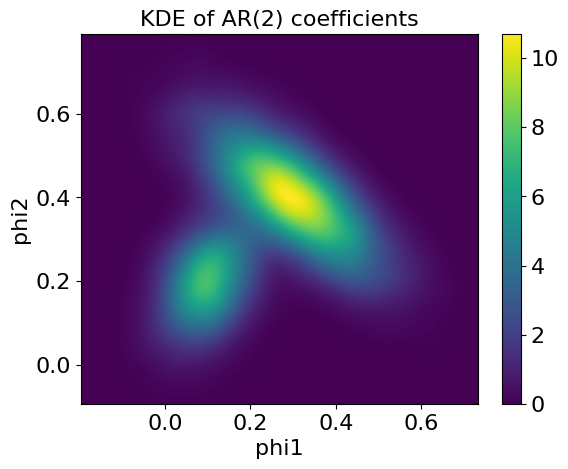

In [10]:
## creating ar2 curve coefficients

centers = [
    np.array([0.1, 0.2]),
    np.array([0.3, 0.4]),
]

covs = [
    np.array([[0.004, 0.002],
              [0.002, 0.008]]),
    np.array([[0.015, -0.01],
              [-0.01, 0.012]])
]

weights = np.array([0.3, 0.7])

ar2_curve_coefffs = sample_mixture(centers, covs, weights, n_samples=8000)
fig = plot_coeff_kde(ar2_curve_coefffs, title="KDE of AR(2) coefficients")
plt.show()


generating curves:  90%|█████████ | 7213/8000 [00:00<00:00, 10225.92it/s]

generating curves: 100%|██████████| 8000/8000 [00:00<00:00, 10242.34it/s]


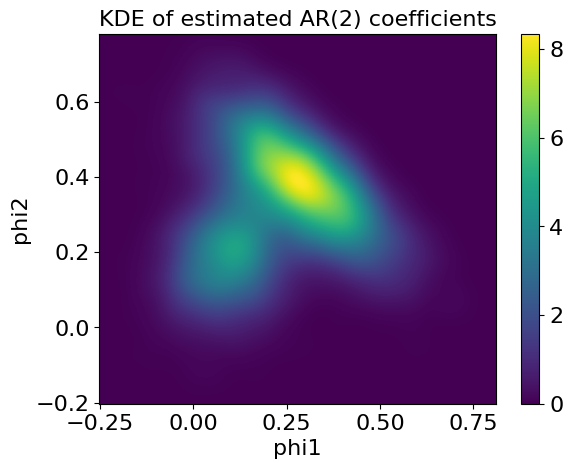

In [11]:

phi_true = ar2_curve_coefffs.copy()
B = phi_true.shape[0]

curves = generate_ar2_curves_from_coeffs(ar2_curve_coefffs, noise_std=1, n_samples=256)   # numpy
curves_t = curves.copy()

estimated_coeffs = estimate_ar2_coeffs_from_cov(curves_t)    # [B, 2]

fig = plot_coeff_kde(
    estimated_coeffs,
    title="KDE of estimated AR(2) coefficients"
)
plt.show()


## AR(1) process

0.07518936655200684


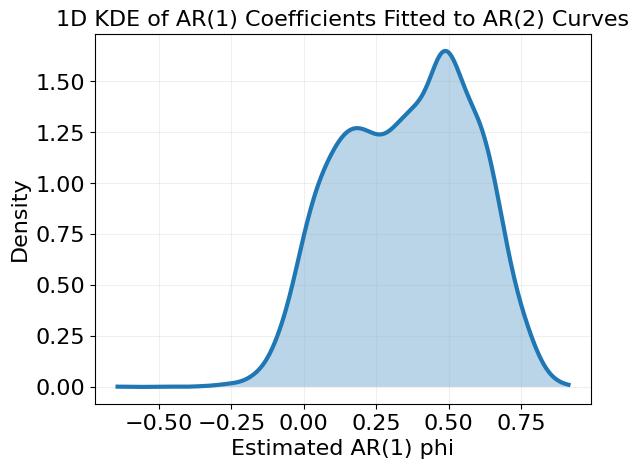

In [12]:
phi_true = ar2_curve_coefffs.copy()
B = phi_true.shape[0]

curves = []
for phi1, phi2 in phi_true:
    curve = generate_ar2_drw(phi1, phi2, noise_std=1, n_samples=256)
    curves.append(curve)

curves_t = np.stack(curves, axis=0)                       # [B, 256]
goodness_of_fit = residual_autocorrelation_ar1(curves_t)
# 3. estimate AR(1) coefficients in parallel
ar1_est = estimate_ar1_coeffs_from_cov(curves_t)        # [B, 1]
ar1_est_np = ar1_est.squeeze(1)     # [B]

# 4. KDE of AR(1) coefficients
kde = gaussian_kde(ar1_est_np)

xgrid = np.linspace(ar1_est_np.min(), ar1_est_np.max(), 400)
density = kde(xgrid)

print(np.abs(goodness_of_fit[0]).mean())
plot_ar1_kde(xgrid, density)
plt.show()


## generate dataset

In [13]:

dataset_size = 100_000
AR2_coeffs = sample_mixture(centers, covs, weights, n_samples=dataset_size)
curves = generate_ar2_curves_from_coeffs(AR2_coeffs, 0.2, 1024)
data_folder = "../../datasets/drw_ar2"
os.makedirs(data_folder, exist_ok=True)
np.save(os.path.join(data_folder, f"curves.npy"), curves)

generating curves: 100%|██████████| 100000/100000 [00:39<00:00, 2539.19it/s]


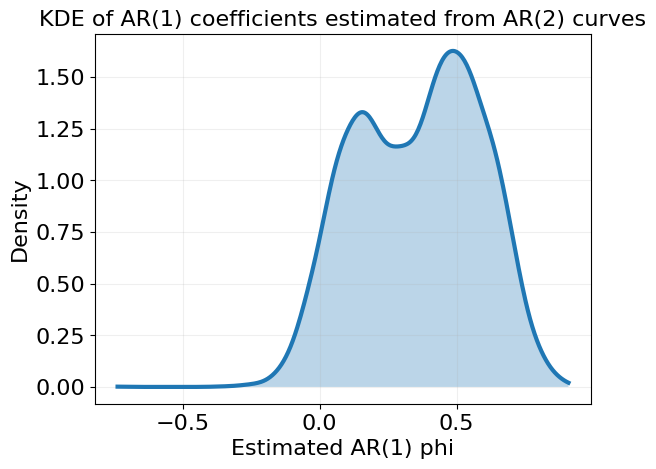

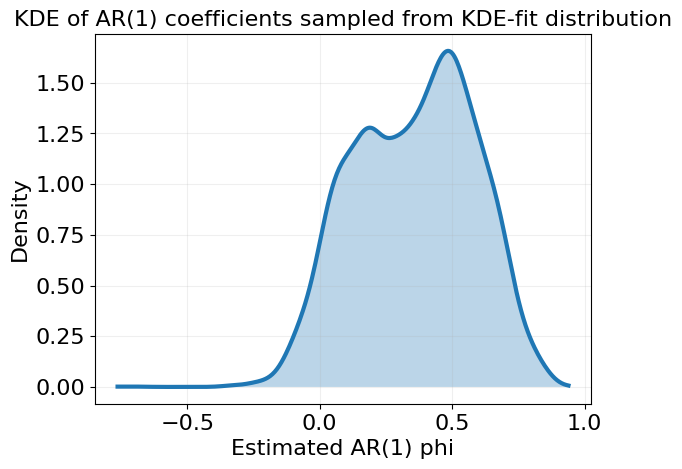

In [14]:
## approximate using KDE

phi_true = ar2_curve_coefffs.copy()
B = phi_true.shape[0]

# --- generate AR(2) curves from true AR(2) coeffs ---
ar2_curves = []
for phi1, phi2 in phi_true:
    curve = generate_ar2_drw(phi1, phi2, noise_std=1, n_samples=256)
    ar2_curves.append(curve)

ar2_curves = np.stack(ar2_curves, axis=0)                       # [B, 256]

# --- estimate AR(1) coeffs for each curve ---
ar1_est = estimate_ar1_coeffs_from_cov(ar2_curves)        # [B, 1]
ar1_est_np = ar1_est.squeeze(1)               # [B]

# --- build KDE of AR(1) coefficients ---
kde = gaussian_kde(ar1_est_np)

# visualization
xgrid = np.linspace(ar1_est_np.min(), ar1_est_np.max(), 400)
density = kde(xgrid)

plot_ar1_kde(xgrid, density, title="KDE of AR(1) coefficients estimated from AR(2) curves")
plt.show()


ar1_new = sample_ar1_from_kde(kde, n_samples=8000, max_val=0.97)


ar1_curves = generate_ar1_curves(ar1_new, noise_std=1, n_samples=256)

kde_new = gaussian_kde(ar1_new)
xgrid2 = np.linspace(ar1_new.min(), ar1_new.max(), 400)
density2 = kde_new(xgrid2)

plot_ar1_kde(xgrid2, density2, title="KDE of AR(1) coefficients sampled from KDE-fit distribution")


### Visualization

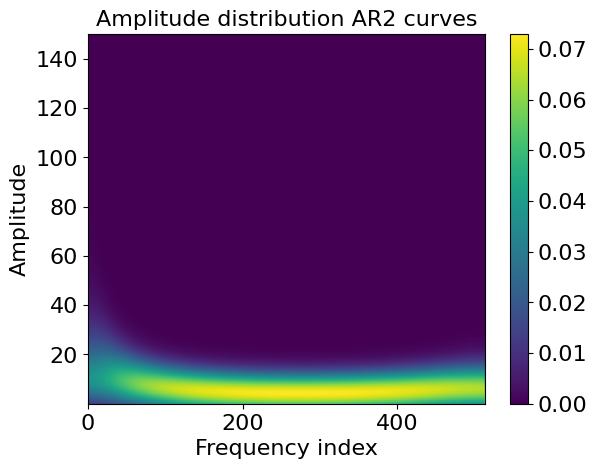

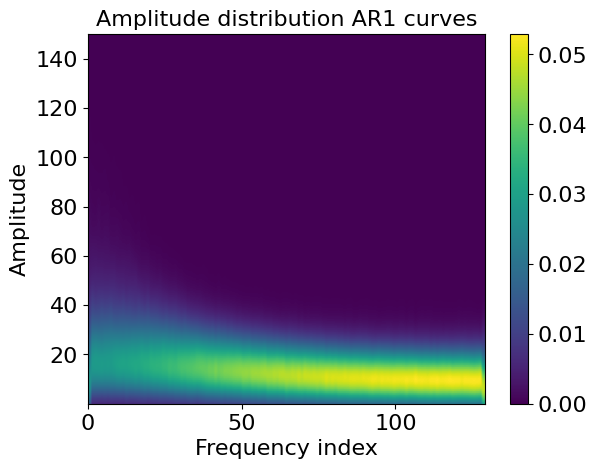

In [15]:
## Amplitude distribution
plt.figure()
plot_amplitudes_distribution(curves, title="Amplitude distribution AR2 curves")
plt.figure()
plot_amplitudes_distribution(ar1_curves, title="Amplitude distribution AR1 curves")
plt.show()


### p value comparison

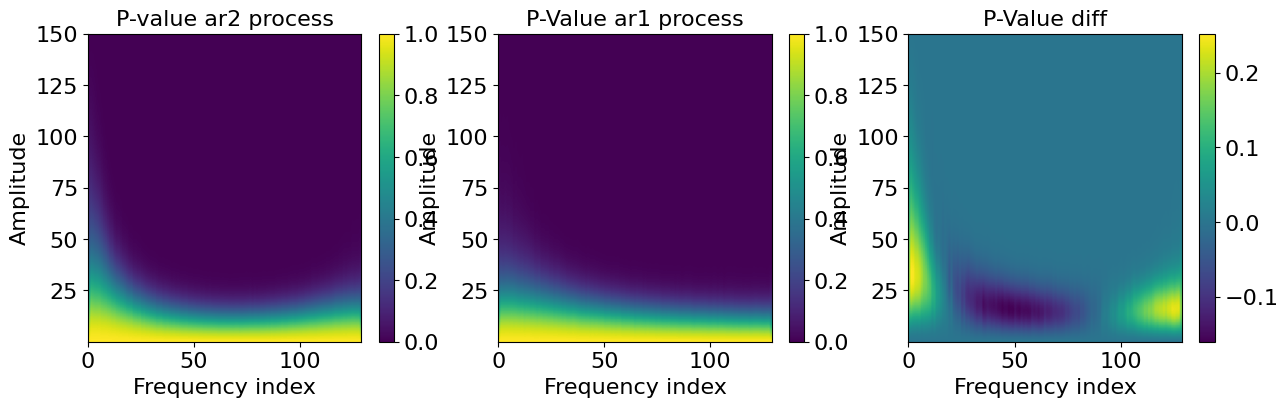

In [16]:
# P-values
def get_p_value_matrix(curves, sigma=5, num_grid=200):
    density_matrix, a_min, a_max = get_density_matrix(curves, sigma, num_grid)

    # tail integral over amplitudes
    rev_cumsum = np.cumsum(density_matrix[::-1, :], axis=0)[::-1, :]
    norm = density_matrix.sum(axis=0, keepdims=True)

    p_value_matrix = rev_cumsum / norm

    return p_value_matrix, a_min, a_max


ar2_p_value_matrix, a_min, a_max = get_p_value_matrix(ar2_curves)
ar1_p_value_matrix, _, _ = get_p_value_matrix(ar1_curves)
plt.figure(figsize=(15, 4))
plt.subplot(131)
plot_p_value_matrix(ar2_p_value_matrix, a_min, a_max, title="P-value ar2 process")
plt.subplot(132)
plot_p_value_matrix(ar1_p_value_matrix, a_min, a_max, title="P-Value ar1 process")
plt.subplot(133)
plot_p_value_matrix(ar2_p_value_matrix - ar1_p_value_matrix, a_min, a_max, title="P-Value diff")
plt.show()

## Overall figure

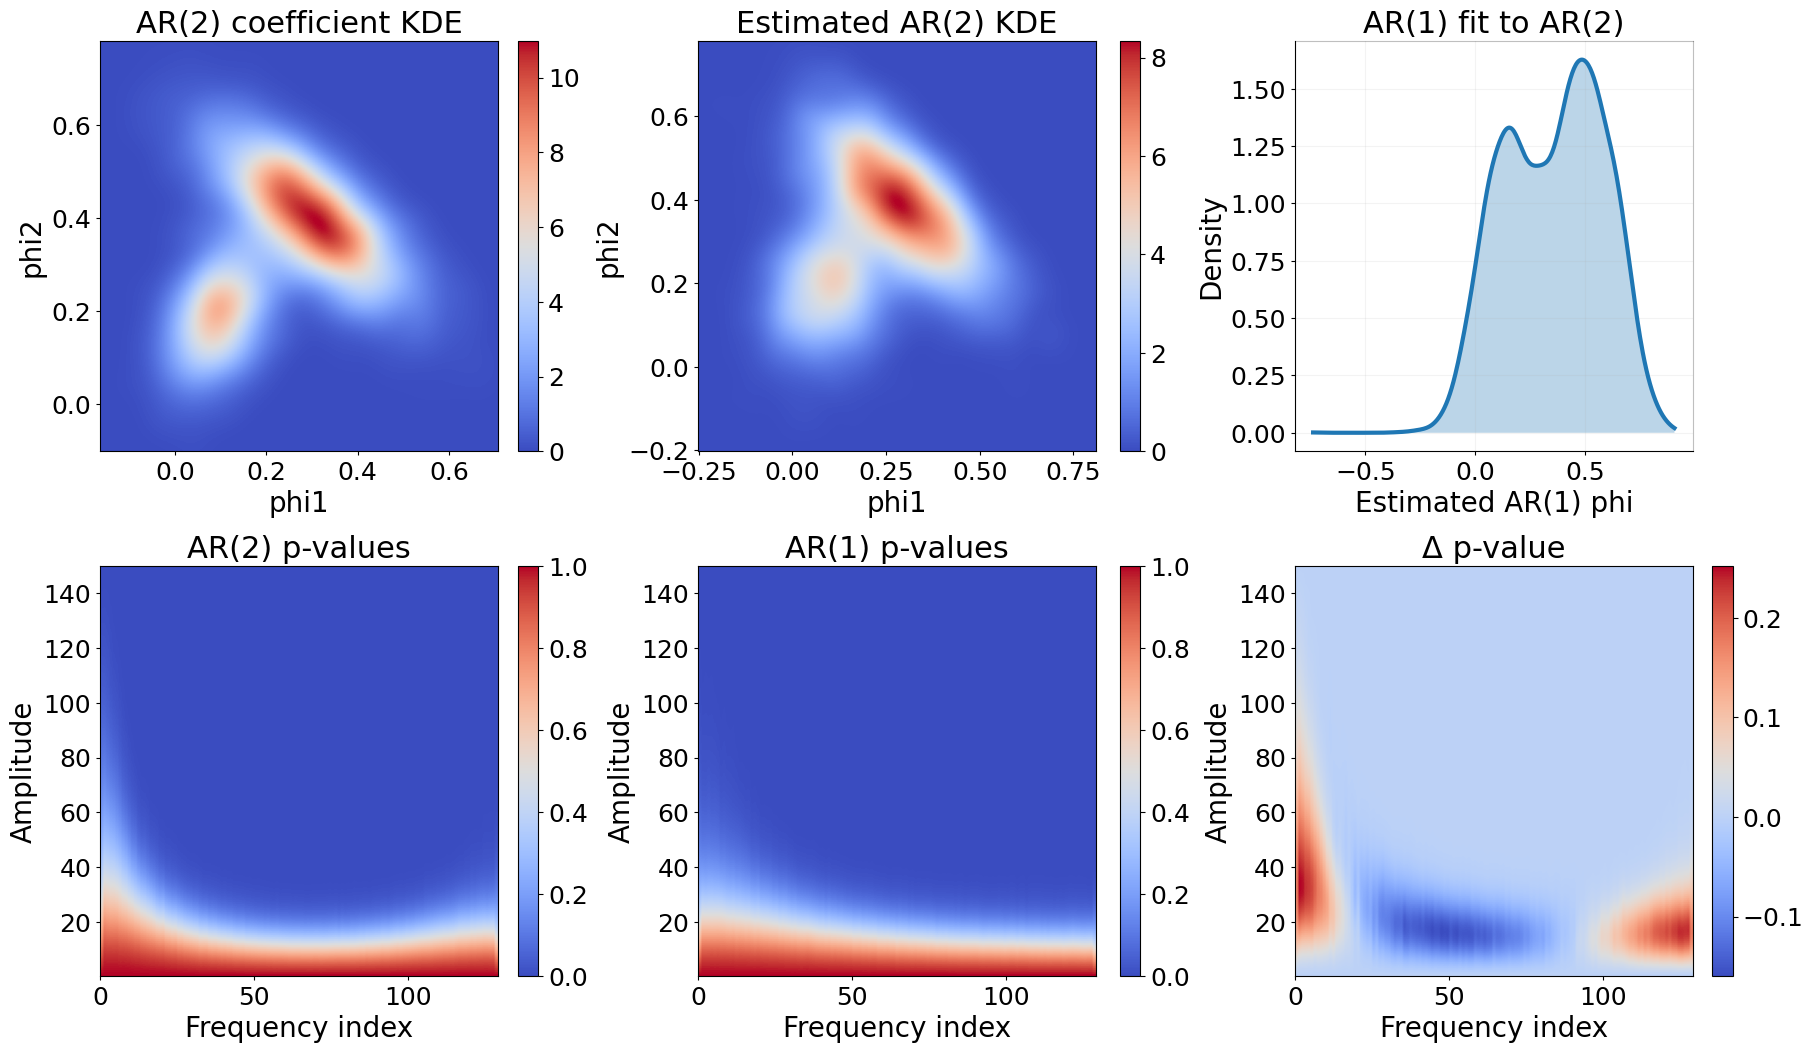

In [26]:
mpl.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

fig, axs = plt.subplots(
    2, 3,
    figsize=(18, 10.5),
    constrained_layout=True
)

fig.set_constrained_layout_pads(
    w_pad=2/72,
    h_pad=6/72,
    wspace=0.01,
    hspace=0.02,
)

plt.sca(axs[0, 0])
ar2_curve_coefffs = sample_mixture(centers, covs, weights, n_samples=8000)
plot_coeff_kde(
    ar2_curve_coefffs,
    title="AR(2) coefficient KDE",
    add_colorbar=True,
)

plt.sca(axs[0, 1])
plot_coeff_kde(
    estimated_coeffs,
    title="Estimated AR(2) KDE",
    add_colorbar=True,
)

plt.sca(axs[0, 2])
plot_ar1_kde(
    xgrid,
    density,
    title="AR(1) fit to AR(2)",
)
axs[0, 2].grid(alpha=0.15)
axs[0, 2].spines["top"].set_alpha(0.25)
axs[0, 2].spines["right"].set_alpha(0.25)

plt.sca(axs[1, 0])
plot_p_value_matrix(
    ar2_p_value_matrix,
    a_min,
    a_max,
    title="AR(2) p-values",
    add_colorbar=True,
)

plt.sca(axs[1, 1])
plot_p_value_matrix(
    ar1_p_value_matrix,
    a_min,
    a_max,
    title="AR(1) p-values",
    add_colorbar=True,
)

plt.sca(axs[1, 2])
plot_p_value_matrix(
    ar2_p_value_matrix - ar1_p_value_matrix,
    a_min,
    a_max,
    title="Δ p-value",
    add_colorbar=True,
)
axs[1, 2].images[0].set_cmap("coolwarm")

cmap = "coolwarm"
axs[0, 0].images[0].set_cmap(cmap)
axs[0, 1].images[0].set_cmap(cmap)
axs[1, 0].images[0].set_cmap(cmap)
axs[1, 1].images[0].set_cmap(cmap)

for ax in axs.ravel():
    ax.tick_params(length=3, width=0.8)
    ax.set_title(ax.get_title(), pad=6)

plt.savefig("fig.png", dpi=500, bbox_inches="tight")
plt.show()